<a href="https://colab.research.google.com/github/mudather490/Nurons_network-projects/blob/main/mnist_digit_classifier_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "digit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8950 - loss: 0.3601 - val_accuracy: 0.9620 - val_loss: 0.1464
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9488 - loss: 0.1732 - val_accuracy: 0.9718 - val_loss: 0.1037
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9621 - loss: 0.1296 - val_accuracy: 0.9733 - val_loss: 0.0924
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9686 - loss: 0.1068 - val_accuracy: 0.9762 - val_loss: 0.0835
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9727 - loss: 0.0893 - val_accuracy: 0.9787 - val_loss: 0.0761


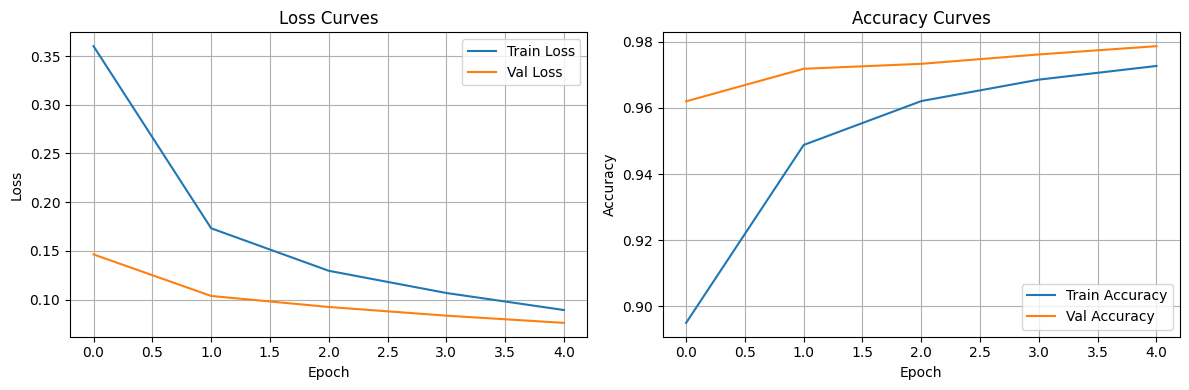


--- Classification Report ---
              precision    recall  f1-score   support

           0     0.9807    0.9837    0.9822       980
           1     0.9834    0.9930    0.9882      1135
           2     0.9739    0.9748    0.9743      1032
           3     0.9665    0.9723    0.9694      1010
           4     0.9698    0.9807    0.9752       982
           5     0.9795    0.9630    0.9712       892
           6     0.9720    0.9791    0.9756       958
           7     0.9655    0.9786    0.9720      1028
           8     0.9771    0.9630    0.9700       974
           9     0.9838    0.9604    0.9719      1009

    accuracy                         0.9752     10000
   macro avg     0.9752    0.9748    0.9750     10000
weighted avg     0.9752    0.9752    0.9752     10000



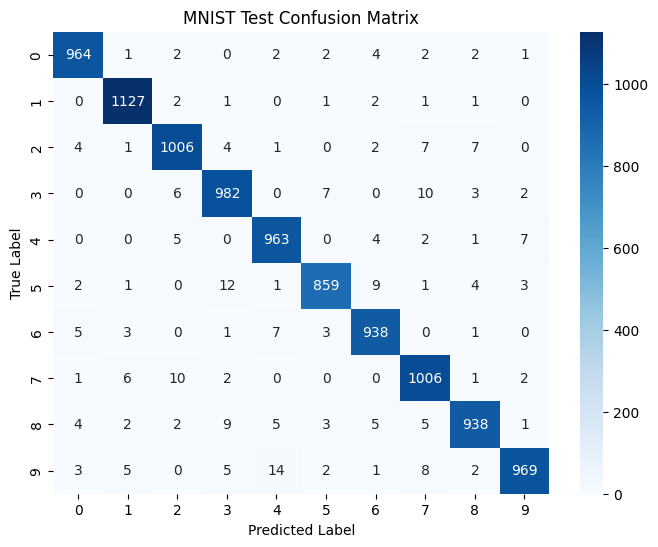

Model persisted to models/mnist_classifier.keras


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

def load_and_preprocess_data():
    """Loads MNIST dataset and normalizes pixel intensities to [0, 1]."""
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    # Scale pixel values to floating point range [0, 1]
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    return (x_train, y_train), (x_test, y_test)

def build_mlp_model(input_shape=(28, 28), num_classes=10) -> keras.Model:
    """Builds a dense Sequential classification network."""
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),  # Regularization to prevent overfitting
        layers.Dense(num_classes, activation='softmax')
    ], name="digit_classifier")

    return model

def plot_training_history(history: keras.callbacks.History):
    """Plots training and validation loss and accuracy curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title('Accuracy Curves')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

def evaluate_model_performance(model: keras.Model, x_test: np.ndarray, y_test: np.ndarray):
    """Evaluates test performance and visualizes the confusion matrix."""
    y_pred_probs = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('MNIST Test Confusion Matrix')
    plt.show()

# Execution Pipeline
if __name__ == "__main__":
    # 1. Pipeline preparation
    (X_train, y_train), (X_test, y_test) = load_and_preprocess_data()

    # 2. Build & Compile
    model = build_mlp_model()
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    model.summary()

    # 3. Train with Validation monitoring
    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    # 4. Diagnostics & Evaluation
    plot_training_history(history)
    evaluate_model_performance(model, X_test, y_test)

    # 5. Correct Native Model Persistence
    os.makedirs("models", exist_ok=True)
    model.save("models/mnist_classifier.keras")
    print("Model persisted to models/mnist_classifier.keras")